# Multivariate Linear Regression
## Using Snowpark Python and Scikit-Learn
### Overview
This script builds and evaluates a linear model to predict housing prices from multiple features:
- AVERAGE_AREA_INCOME
- AVERAGE_HOME_AGE
- AVERAGE_NUMBER_OF_ROOMS
- AVERAGE_NUMBER_OF_BEDROOMS
- AREA_POPULATION

Remember that the simple regression predicts price from AVERAGE_AREA_INCOME alone. 

We'll see whether this model -- using additional features for prediction -- achieves better accuracy (as measured with the same test data).

Steps:
- Setup
- Load and Explore Data
- Prepare Data for Regression
- Train and Examine Linear Model
- Evaluate the Model
- Examine the Model Visually
### Setup

In [1]:
import snowflake.snowpark
from snowflake.snowpark.session import Session

# config_dir = '/home/jovyan/.ssh'
# configfile = config_dir + '/sf_config'

* Load configuration and connect to Snowflake

In [2]:
# My code for Snowflake account connection

CONFIG_DIR = '/Users/richardkirk/.ssh'
CONFIGFILE = CONFIG_DIR + '/sf_config'


# Load configuration file
with open(CONFIGFILE) as f:
    lines = f.readlines()
    
# Convert configuration to a properties map
props = {}
for line in lines:
    (key, value) = line.split('=')
    props.update({key.lower() : value[0:-1]})
    
# Convert the private key to a DER-encoded bytes object
from cryptography.hazmat.primitives import serialization
from cryptography.hazmat.backends import default_backend

with open(props['private_key_file'], "rb") as key:
    private_key = serialization.load_pem_private_key(
        key.read(),
        password=None,
        backend=default_backend()
    )
    
private_key_bytes = private_key.private_bytes(
    encoding=serialization.Encoding.DER,
    format=serialization.PrivateFormat.PKCS8,
    encryption_algorithm=serialization.NoEncryption()
)

# Connect to Snowflake
session = Session.builder.configs({**props, **{"private_key": private_key_bytes}}).create()

### Load and Explore Data
* Define a Snowpark DataFrame on Snowflake table **usa_housing**.

In [3]:
housingDF = session.table('data_science_db.housing.usa_housing')

* Examine the data.

In [4]:
housingDF.schema.fields

[StructField('AVERAGE_AREA_INCOME', DoubleType(), nullable=False),
 StructField('AVERAGE_HOME_AGE', DoubleType(), nullable=False),
 StructField('AVERAGE_NUMBER_OF_ROOMS', DoubleType(), nullable=False),
 StructField('AVERAGE_NUMBER_OF_BEDROOMS', DoubleType(), nullable=False),
 StructField('AREA_POPULATION', DoubleType(), nullable=False),
 StructField('PRICE', DoubleType(), nullable=False),
 StructField('ADDRESS', StringType(200), nullable=False)]

In [5]:
housingDF.count()

5000

In [6]:
housingDF.show(5)

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"AVERAGE_AREA_INCOME"  |"AVERAGE_HOME_AGE"  |"AVERAGE_NUMBER_OF_ROOMS"  |"AVERAGE_NUMBER_OF_BEDROOMS"  |"AREA_POPULATION"  |"PRICE"     |"ADDRESS"                       |
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|38022.2                |7.5                 |5.5                        |2.5                           |5887.0             |2963419.95  |7059 Creek Ave, Franklin, CA    |
|23681.45               |5.5                 |7.0                        |5.5                           |62682.0            |3396385.88  |2121 Forest Ave, Newport, TX    |
|83915.82               |6.0                 |4.0                        |5.0                           |63304.0            |4373917.93  |76

* Look at the correlation between candidate features and the home price. (Note that this cell combines the procedure of a Python loop with the correlation function computed by Snowflake.)

In [7]:
for feature in ['average_area_income', 'average_home_age', 'average_number_of_rooms',
                'average_number_of_bedrooms', 'area_population']:
    print(feature.ljust(28), housingDF.stat.corr(feature, 'price'))

average_area_income          0.7131847449261429
average_home_age             0.5133071416496534
average_number_of_rooms      0.25847739652300983
average_number_of_bedrooms   -0.00927092968052771
area_population              0.37864371014950204


*Interpretation:* The system shows some correlation between price and the other variables.

### Prepare Data for Regression

In [9]:
session.sql("USE DATABASE DATA_SCIENCE_DB").collect() # I had to add this, else get error below that db not set

# Drop address column
housingDF = housingDF.drop('address')

# Create train and test sets
(housing_trainDF, housing_testDF) = housingDF.random_split([0.8, 0.2], seed=42)

# Get train and test set sizes
(housing_trainDF.count(), housing_testDF.count())

(3962, 1038)

- Get Pandas DataFrames for training in Scikit-Learn

In [10]:
train_x_PDF = housing_trainDF.drop('price').toPandas()
train_y_PDF = housing_trainDF.select('price').toPandas()

### Train and Examine Linear Model
- Fit the model to the training data

In [11]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(train_x_PDF, train_y_PDF)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


- Examine the model parameters

In [12]:
print('Model intercept: ', lin_reg.intercept_[0])

Model intercept:  9964.607528512832


In [13]:
import pandas as pd
coeff_PDF = pd.DataFrame(lin_reg.coef_[0], train_x_PDF.columns, columns=['Coefficient'])
coeff_PDF

,Coefficient
AVERAGE_AREA_INCOME,21.480033
AVERAGE_HOME_AGE,164486.849671
AVERAGE_NUMBER_OF_ROOMS,123046.861653
AVERAGE_NUMBER_OF_BEDROOMS,-845.280951
AREA_POPULATION,15.246039


### Evaluate the Model
- Predict results for the test set

In [14]:
# Fetch test data as Pandas DataFrames
test_x_PDF = housing_testDF.drop('price').toPandas()
test_y_PDF = housing_testDF.select('price').toPandas()

# Run predictions
predictions = lin_reg.predict(test_x_PDF)

In [ ]:
# MyNote: train_x_PDF has just multiple columns , I think is why this is MULTIVARIATE linear regression, not univariate
train_x_PDF.head(5)

,AVERAGE_AREA_INCOME,AVERAGE_HOME_AGE,AVERAGE_NUMBER_OF_ROOMS,AVERAGE_NUMBER_OF_BEDROOMS,AREA_POPULATION
0,38022.20,7.5,5.5,2.5,5887.0
1,23681.45,5.5,7.0,5.5,62682.0
2,105858.13,7.5,7.0,5.0,34036.0
3,56647.46,3.0,7.0,3.0,39489.0
4,60609.48,4.5,4.5,3.0,49159.0


- Display a few predictions

In [15]:
predictions_PDF = pd.DataFrame(predictions, columns=['prediction'])
test_y_PDF.join(predictions_PDF)[:5]

,PRICE,prediction
0,4373917.93,4.252497e+06
1,4362049.94,4.288746e+06
2,4241004.00,4.391286e+06
3,4007122.86,4.099495e+06
4,3695170.92,3.507896e+06


- Calculate evaluation metrics

Compare these metrics to the metrics from the univariate linear regression model.

In [16]:
from sklearn import metrics
print('r2:\t', metrics.r2_score(test_y_PDF, predictions))

r2:	 0.9788284827813101


In [19]:
import math
print('rmse:\t', round(math.sqrt(metrics.mean_squared_error(test_y_PDF, predictions)), 2))

rmse:	 113776.17


### Examine the Model Visually

- Scatter plot of predictions vs values 

(A "perfect" and unrealistic model would show all points on a single line with intercept 0 and slope 1.)

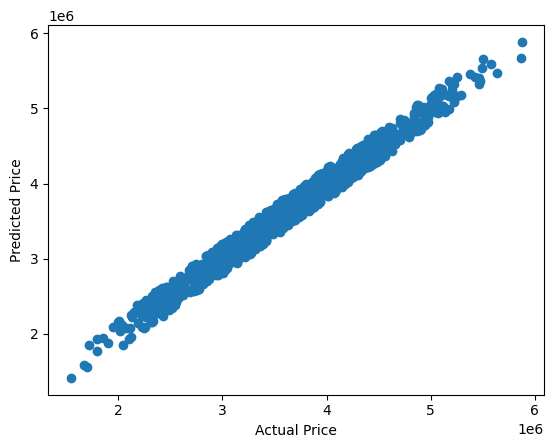

In [20]:
import matplotlib.pyplot as plt
plt.scatter(test_y_PDF, predictions)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

- Distribution of prediction errors

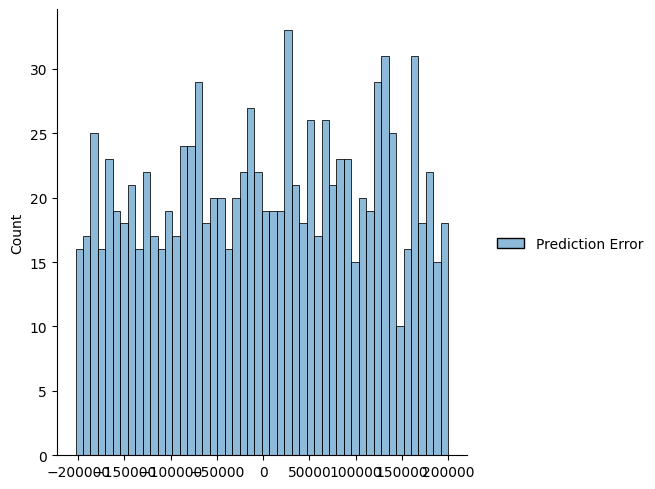

In [21]:
import seaborn as sns
prediction_errors = test_y_PDF - predictions
prediction_errors = prediction_errors.rename(columns={"PRICE" : "Prediction Error"})
sns.displot(prediction_errors, bins=50)

### MyNote: Multivariate vs univariate Linear Regression

Multivariate seems better than univariate based on the above results